# Land Degradation and Rangeland Dynamics

This lesson detects vegetation decline and degradation across an approximate
Sahelian AOI in northern Burkina Faso.

**Learning objectives**

- interpret NDVI trend as a land-condition signal;
- distinguish linear trends from structural breakpoints;
- compare Random Forest and LightGBM model choices;
- interpret degradation classes and SHAP drivers.


## 1. Prepare the notebook session

This cell imports the tools used throughout the lesson and loads configuration
from a local `.env` file. The Earth Engine project identifier is configuration,
not analysis data, so it is kept outside the notebook.

Before running the notebook:

1. copy `.env.example` to `.env`;
2. replace the placeholder with your Google Earth Engine project ID;
3. run `earthengine authenticate` once in a terminal;
4. select the **Climate Change Workflows** kernel.

The `%matplotlib inline` backend renders figures directly below each plotting cell.


In [1]:
from dataclasses import asdict
from pathlib import Path
import os

from IPython import get_ipython

ipython = get_ipython()
if ipython is not None:
    ipython.run_line_magic("matplotlib", "inline")

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from dotenv import load_dotenv

from climate_change import USE_CASE_REGISTRY, run_analysis

WORKSPACE = Path.cwd()
if not (WORKSPACE / ".venv").exists() and (WORKSPACE.parent / ".venv").exists():
    WORKSPACE = WORKSPACE.parent

load_dotenv(WORKSPACE / ".env")
GEE_PROJECT = os.environ.get("GEE_PROJECT", "").strip()
if not GEE_PROJECT:
    raise RuntimeError("Create .env from .env.example and set GEE_PROJECT.")

OUTPUT_DIR = WORKSPACE / "outputs"
REPORT_DIR = WORKSPACE / "reports"
OUTPUT_DIR.mkdir(exist_ok=True)
REPORT_DIR.mkdir(exist_ok=True)

print("Workspace:", WORKSPACE)
print("Earth Engine project configured:", bool(GEE_PROJECT))


Workspace: /home/odero-george/workspace/climate-change-workflows
Earth Engine project configured: True


## 2. Inspect the package registry

The registry is the package's catalogue of supported analyses. It documents the
recommended date range, dependent variable, input variables, and selectable models.
Inspecting it before running an analysis helps us choose scientifically sensible
parameters instead of treating the model as a black box.


In [2]:
info = USE_CASE_REGISTRY["land_degradation"]
print(info.name)
print("\nPurpose:", info.description)
print("\nPredicted variable:", info.dependent_variable)
print("\nDate guidance:", info.date_guidance)
print("\nAvailable models:")
for option in info.model_options:
    marker = " (recommended)" if option.recommended else ""
    print(f"  - {option.id}: {option.label}{marker} — {option.note}")

Rangeland Dynamics & Land Degradation

Purpose: This tool detects where land is losing its ability to support vegetation and livestock by analysing satellite imagery over time. It identifies degraded areas, measures how severe the degradation is, and shows when the decline started.

Predicted variable: Land degradation severity score (0–100) and change class

Date guidance: Select at least 5 years for meaningful trend detection; 10+ years recommended.

Available models:
  - rf: Random Forest — Fast change detection
  - lgbm: LightGBM (recommended) — Best land baseline
  - ensemble: Ensemble (RF + LightGBM) — Best overall · majority vote


## 3. Mathematical/Scientific model

Annual vegetation change is summarised with ordinary least squares:

$$
\mathrm{NDVI}_t = \beta_0 + \beta_1t + \varepsilon_t
$$

A negative slope $\beta_1<0$ indicates declining greenness. The coefficient
of determination is:

$$
R^2 = 1-\frac{\sum_t(y_t-\hat y_t)^2}
{\sum_t(y_t-\bar y)^2}
$$

Mann–Kendall testing assesses whether the monotonic trend is statistically
significant, while breakpoint detection identifies years when the time-series
Behaviour changes abruptly. The classifier then combines trend, bare-soil,
rainfall, terrain, and land-cover variables.

## 4. Configure a long-term degradation study

Trend detection requires a sufficiently long record. This example uses ten
complete years at 1 km resolution. The AOI is illustrative; operational work
should use an authoritative administrative or ecological boundary.


In [3]:
aoi = {
    "type": "Polygon",
    "coordinates": [[
        [-2.80, 13.20], [-0.20, 13.20], [-0.20, 15.00],
        [-2.80, 15.00], [-2.80, 13.20],
    ]],
}

analysis_args = {
    "module": "land_degradation",
    "aoi_geojson": aoi,
    "start_date": "2015-01-01",
    "end_date": "2024-12-31",
    "country": "Burkina Faso",
    "gee_project": GEE_PROJECT,
    "extra_params": {
        "model_type": "lgbm",
        "n_pixels": 3000,
        "scale": 1000,
        "output_dir": str(OUTPUT_DIR),
        "prefix": "burkina_land_degradation",
    },
}
analysis_args

{'module': 'land_degradation',
 'aoi_geojson': {'type': 'Polygon',
  'coordinates': [[[-2.8, 13.2],
    [-0.2, 13.2],
    [-0.2, 15.0],
    [-2.8, 15.0],
    [-2.8, 13.2]]]},
 'start_date': '2015-01-01',
 'end_date': '2024-12-31',
 'country': 'Burkina Faso',
 'gee_project': 'parallelprocessing-433914',
 'extra_params': {'model_type': 'lgbm',
  'n_pixels': 3000,
  'scale': 1000,
  'output_dir': '/home/odero-george/workspace/climate-change-workflows/outputs',
  'prefix': 'burkina_land_degradation'}}

## 5. Run the analysis

`run_analysis` is asynchronous because data retrieval and model execution may be
long-running operations. Jupyter supports top-level `await`, so no explicit event
loop is required here.

The first run may take several minutes. Runtime depends on AOI size, temporal
coverage, Earth Engine quota, sampling resolution, and model choice.


In [4]:
output = await run_analysis(**analysis_args)
print("Analysis complete:", output.module)

2026-07-03 15:31:31,082 - distributed.http.proxy - INFO - To route to workers diagnostics web server please install jupyter-server-proxy: python -m pip install jupyter-server-proxy
2026-07-03 15:31:31,112 - distributed.scheduler - INFO - State start
2026-07-03 15:31:31,113 - distributed.diskutils - INFO - Found stale lock file and directory '/tmp/dask-scratch-space/scheduler-7jymun5i', purging
2026-07-03 15:31:31,118 - distributed.scheduler - INFO -   Scheduler at:     tcp://127.0.0.1:38633
2026-07-03 15:31:31,118 - distributed.scheduler - INFO -   dashboard at:  http://127.0.0.1:8787/status
2026-07-03 15:31:31,119 - distributed.scheduler - INFO - Registering Worker plugin shuffle
2026-07-03 15:31:31,133 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:45103'
2026-07-03 15:31:31,137 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:40189'
2026-07-03 15:31:31,141 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:39745'
2026-07

Analysis complete: land_degradation


## 6. Inspect the common output contract

Every use case returns an `AnalysisOutput` object with the same top-level fields:

- `stats`: summary indicators suitable for dashboards and reports;
- `charts`: structured time-series and distribution data;
- `geojson`: spatial features for a web map or GIS;
- `raster_path`: generated Cloud-Optimized GeoTIFF path(s), when available;
- `shap`: feature-importance information for supported models;
- `metadata`: model, period, country, and optional report information.

The internal keys of `stats` and `charts` remain specific to each scientific domain.


In [5]:
print("Module:", output.module)
print("Raster output:", output.raster_path)
print("GeoJSON feature count:", len(output.geojson.get("features", [])))
print("Chart payloads:", sorted(output.charts))
print("Metadata:", output.metadata)

pd.Series(output.stats, name="value").to_frame()

Module: land_degradation
Raster output: {'degradation_risk': '/home/odero-george/workspace/climate-change-workflows/outputs/burkina_land_degradation_degradation_risk.tif'}
GeoJSON feature count: 1
Chart payloads: ['model_performance', 'riskDist', 'shap', 'timeSeries', 'trend']
Metadata: {'model': 'lgbm', 'country': 'Burkina Faso', 'start_date': '2015-01-01', 'end_date': '2024-12-31', 'raster': {'degradation_risk': '/home/odero-george/workspace/climate-change-workflows/outputs/burkina_land_degradation_degradation_risk.tif'}}


,value
model_type,lgbm
n_pixels_sampled,2990
degraded_label_pct,30.0
rf_cv_f1,0.9315
rf_f1,0.9404
rf_accuracy,0.9398
lgbm_cv_f1,0.9599
lgbm_f1,0.9597
lgbm_accuracy,0.9599
ensemble_f1,0.9472


## 7. Visualize degradation and NDVI change

The distribution chart summarizes classified pixels. The annual NDVI panel
shows observations, the fitted OLS trend, and any detected structural
breakpoints. A breakpoint is evidence of a regime shift, not proof of its cause;
land-use history and field observations are needed for attribution.


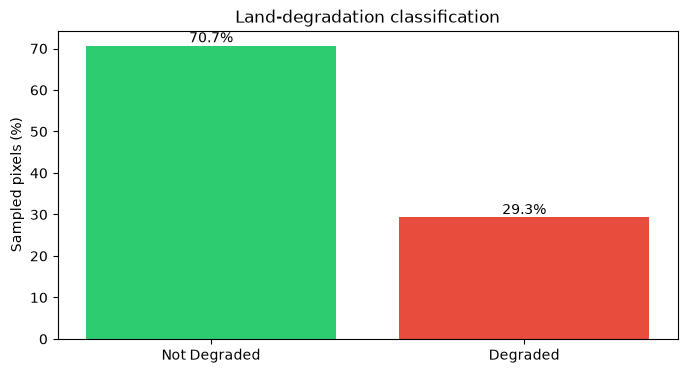

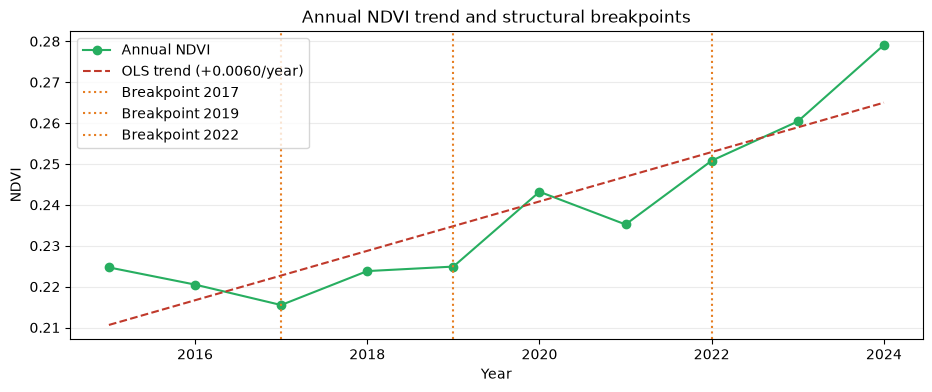

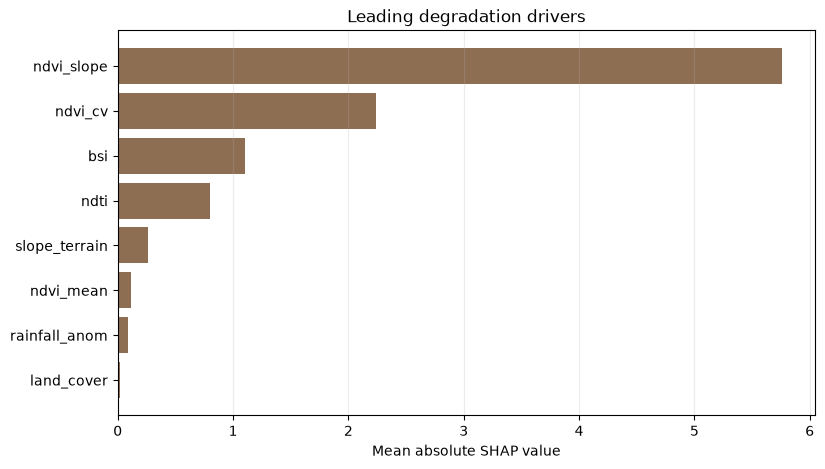

In [6]:
risk = output.charts.get("riskDist", {})
if risk.get("labels"):
    fig, ax = plt.subplots(figsize=(8, 4))
    bars = ax.bar(risk["labels"], risk["data"], color=risk.get("colors"))
    ax.bar_label(bars, fmt="%.1f%%")
    ax.set_ylabel("Sampled pixels (%)")
    ax.set_title("Land-degradation classification")
    plt.show()

series = output.charts.get("timeSeries", {})
datasets = series.get("datasets", [])
labels = np.asarray(series.get("labels", []), dtype=float)
if datasets and labels.size:
    ndvi = np.asarray(datasets[0]["data"], dtype=float)
    fig, ax = plt.subplots(figsize=(11, 4))
    ax.plot(labels, ndvi, color="#27AE60", marker="o", label="Annual NDVI")

    trend = output.charts.get("trend", {})
    slope = trend.get("ndvi_trend_per_year", output.stats.get("ndvi_trend_per_year"))
    valid = np.isfinite(ndvi)
    if slope is not None and valid.sum() >= 2:
        intercept = np.nanmean(ndvi) - slope * np.nanmean(labels[valid])
        ax.plot(labels, intercept + slope * labels, "--", color="#C0392B",
                label=f"OLS trend ({slope:+.4f}/year)")

    breakpoints = trend.get("breakpoint_years",
                            output.stats.get("breakpoint_years", []))
    for year in breakpoints:
        ax.axvline(year, color="#E67E22", linestyle=":",
                   label=f"Breakpoint {year}")

    ax.set_xlabel("Year")
    ax.set_ylabel("NDVI")
    ax.set_title("Annual NDVI trend and structural breakpoints")
    ax.legend()
    ax.grid(axis="y", alpha=0.25)
    plt.show()

shap = output.shap or output.charts.get("shap", {})
if shap.get("features"):
    features = shap["features"][:10][::-1]
    values = shap["mean_abs_shap"][:10][::-1]
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.barh(features, values, color="#8E6E53")
    ax.set_xlabel("Mean absolute SHAP value")
    ax.set_title("Leading degradation drivers")
    ax.grid(axis="x", alpha=0.25)
    plt.show()

## 8. Locate spatial artifacts

The analysis may produce GeoJSON features and one or more Cloud-Optimized GeoTIFF
files. GeoJSON is convenient for APIs and interactive maps, while COGs preserve
continuous raster coverage for GIS software and cloud-native access.

The following cell reports the artifacts without attempting to display a large
raster inside the notebook.


In [7]:
print("GeoJSON type:", output.geojson.get("type"))
print("GeoJSON features:", len(output.geojson.get("features", [])))
print("Raster path(s):", output.raster_path)

if output.raster_path:
    paths = (
        output.raster_path.values()
        if isinstance(output.raster_path, dict)
        else [output.raster_path]
    )
    for path in paths:
        artifact = Path(path)
        print(f"{artifact.name}: exists={artifact.exists()}")


GeoJSON type: FeatureCollection
GeoJSON features: 1
Raster path(s): {'degradation_risk': '/home/odero-george/workspace/climate-change-workflows/outputs/burkina_land_degradation_degradation_risk.tif'}
burkina_land_degradation_degradation_risk.tif: exists=True


## 9. Optional: generate a PDF report

Setting `GENERATE_REPORT` to `True` reruns the same request and asks the package to
assemble a PDF containing metadata, statistics, charts, interpretation text, and
available map content. Keep it `False` during exploration to avoid an unnecessary
second model run.


In [8]:
GENERATE_REPORT = True

if GENERATE_REPORT:
    report_output = await run_analysis(
        **analysis_args,
        report_output_dir=str(REPORT_DIR),
    )
    print("Report:", report_output.metadata.get("report_path"))

Report: /home/odero-george/workspace/climate-change-workflows/reports/land_degradation_20260703_123300.pdf
